LOADING DATASETS

Process Memory (PM) Dataset Shape: (10186, 9)
UGRansome Dataset Shape: (10000, 14)

MISSING VALUES ANALYSIS: Process Memory (PM)

Missing Values Summary:
--------------------------------------------------------------------------------
  Column  Missing_Count  Missing_Percentage Data_Type  Unique_Values                        Sample_Values
  family           1364           13.390929    object            621       [Zeppelin, Zeppelin, Zeppelin]
       r              0            0.000000     int64            245                       [69, 120, 120]
      rw              0            0.000000     int64            399                       [71, 102, 101]
     rwc              0            0.000000     int64            119                         [28, 29, 29]
      rx              0            0.000000     int64            118                         [26, 50, 50]
     rwx              0            0.000000     int64             90                            [5, 6, 6]
    r

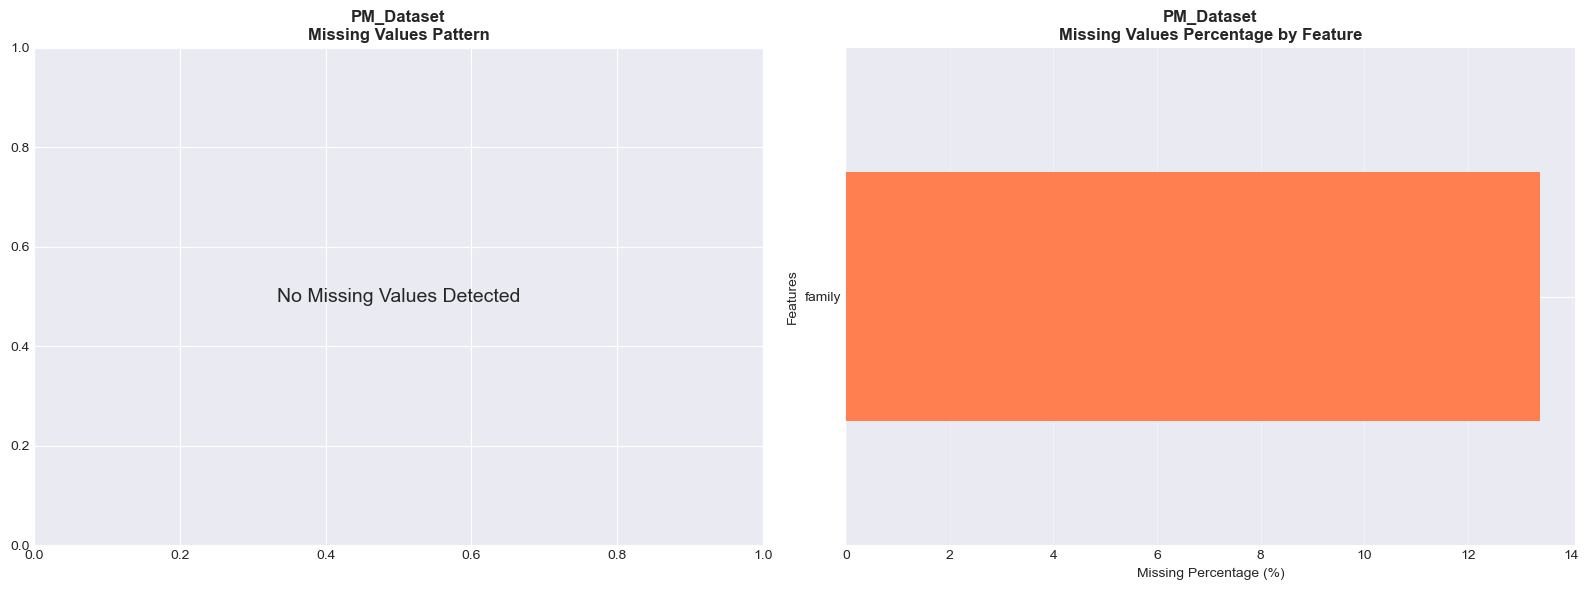


✓ Visualization saved as 'PM_Dataset_missing_values.png'


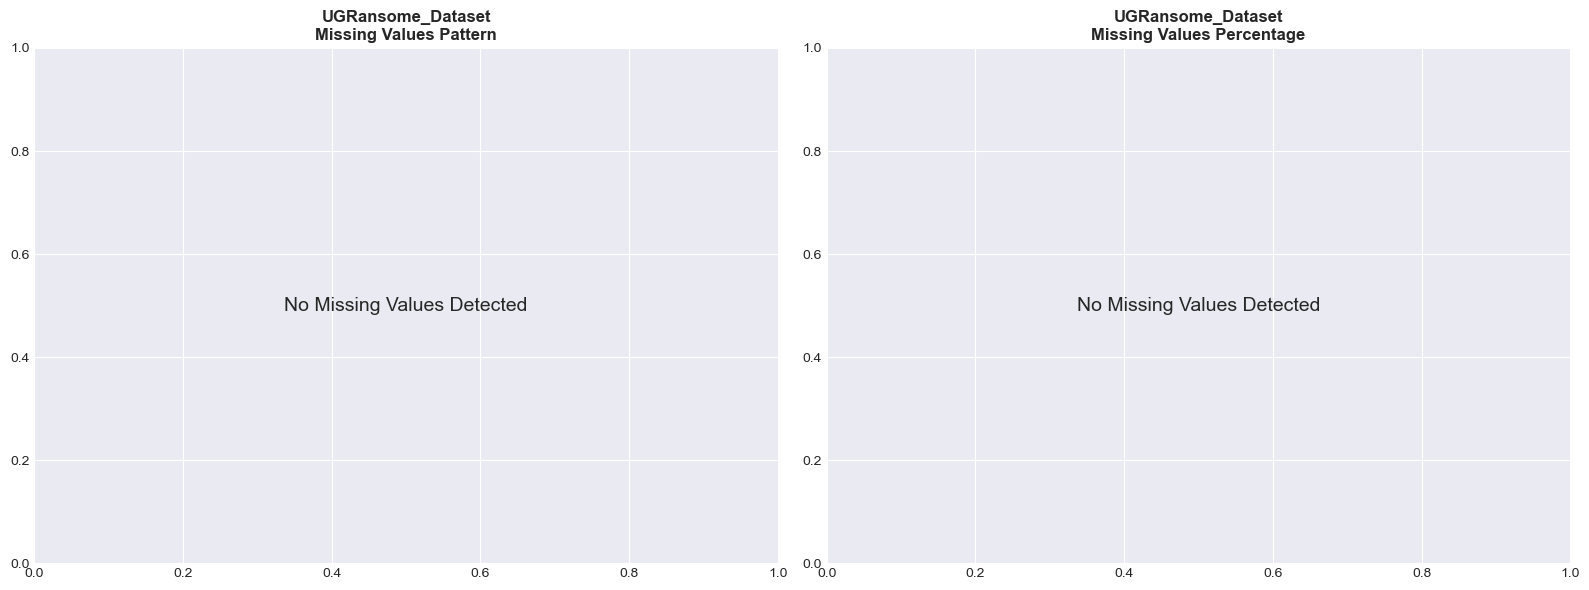


✓ Visualization saved as 'UGRansome_Dataset_missing_values.png'

SECTION 2.1.1 COMPLETE: Missing Values Analysis Finished


In [6]:
"""
Section 2.1.1: Description of Missing/Unknown Values

"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options for better visibility
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

# Load the datasets
print("="*80)
print("LOADING DATASETS")
print("="*80)

pm_df = pd.read_csv('PM.csv')
ugransome_df = pd.read_csv('UGRansome.csv')

print(f"\nProcess Memory (PM) Dataset Shape: {pm_df.shape}")
print(f"UGRansome Dataset Shape: {ugransome_df.shape}")

# ============================================================================
# SECTION 2.1.1: MISSING/UNKNOWN VALUES ANALYSIS
# ============================================================================

def analyze_missing_values(df, dataset_name):
    """
    Comprehensive analysis of missing and unknown values in the dataset
    """
    print(f"\n{'='*80}")
    print(f"MISSING VALUES ANALYSIS: {dataset_name}")
    print(f"{'='*80}\n")
    
    # 1. Basic missing values count
    missing_count = df.isnull().sum()
    missing_percent = (df.isnull().sum() / len(df)) * 100
    
    # 2. Check for unknown values (common representations)
    unknown_patterns = ['unknown', 'Unknown', 'UNKNOWN', 'NA', 'N/A', 
                       'null', 'NULL', '?', '', ' ', 'nan', 'NaN']
    
    # Create missing values summary
    missing_summary = pd.DataFrame({
        'Column': df.columns,
        'Missing_Count': missing_count.values,
        'Missing_Percentage': missing_percent.values,
        'Data_Type': df.dtypes.values,
        'Unique_Values': [df[col].nunique() for col in df.columns],
        'Sample_Values': [df[col].dropna().head(3).tolist() if len(df[col].dropna()) > 0 
                         else [] for col in df.columns]
    })
    
    # Sort by missing percentage
    missing_summary = missing_summary.sort_values('Missing_Percentage', 
                                                   ascending=False)
    
    print("Missing Values Summary:")
    print("-" * 80)
    print(missing_summary.to_string(index=False))
    
    # 3. Check for columns with unknown string patterns
    print(f"\n\nChecking for Unknown Value Patterns:")
    print("-" * 80)
    
    unknown_found = False
    for col in df.columns:
        if df[col].dtype == 'object':
            unknown_count = df[col].isin(unknown_patterns).sum()
            if unknown_count > 0:
                unknown_found = True
                print(f"{col}: {unknown_count} unknown values found")
    
    if not unknown_found:
        print("No common unknown value patterns detected in string columns.")
    
    # 4. Statistical summary
    print(f"\n\nStatistical Summary:")
    print("-" * 80)
    total_cells = df.shape[0] * df.shape[1]
    total_missing = df.isnull().sum().sum()
    print(f"Total cells: {total_cells:,}")
    print(f"Total missing cells: {total_missing:,}")
    print(f"Overall missing percentage: {(total_missing/total_cells)*100:.2f}%")
    print(f"Columns with missing values: {(missing_count > 0).sum()}")
    print(f"Complete columns (no missing): {(missing_count == 0).sum()}")
    
    # 5. Identify columns with high missing rates (>50%)
    high_missing = missing_summary[missing_summary['Missing_Percentage'] > 50]
    if len(high_missing) > 0:
        print(f"\n⚠️  Columns with >50% missing values:")
        print(high_missing[['Column', 'Missing_Percentage']].to_string(index=False))
    
    return missing_summary

# Analyze both datasets
pm_missing = analyze_missing_values(pm_df, "Process Memory (PM)")
ugr_missing = analyze_missing_values(ugransome_df, "UGRansome Network Traffic")

# ============================================================================
# VISUALIZATION: MISSING VALUES HEATMAP
# ============================================================================

def plot_missing_values(df, dataset_name):
    """
    Create visualization of missing values pattern
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot 1: Missing values heatmap (sample of rows)
    sample_size = min(1000, len(df))
    missing_data = df.head(sample_size).isnull()
    
    if missing_data.any().any():
        sns.heatmap(missing_data.T, cbar=True, cmap='YlOrRd', 
                   yticklabels=True, xticklabels=False, ax=axes[0])
        axes[0].set_title(f'{dataset_name}\nMissing Values Pattern (First {sample_size} rows)', 
                         fontsize=12, fontweight='bold')
        axes[0].set_xlabel('Sample Index')
        axes[0].set_ylabel('Features')
    else:
        axes[0].text(0.5, 0.5, 'No Missing Values Detected', 
                    ha='center', va='center', fontsize=14)
        axes[0].set_title(f'{dataset_name}\nMissing Values Pattern', 
                         fontsize=12, fontweight='bold')
    
    # Plot 2: Missing values bar chart
    missing_percent = (df.isnull().sum() / len(df)) * 100
    missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=True)
    
    if len(missing_percent) > 0:
        missing_percent.plot(kind='barh', ax=axes[1], color='coral')
        axes[1].set_title(f'{dataset_name}\nMissing Values Percentage by Feature', 
                         fontsize=12, fontweight='bold')
        axes[1].set_xlabel('Missing Percentage (%)')
        axes[1].set_ylabel('Features')
        axes[1].grid(axis='x', alpha=0.3)
    else:
        axes[1].text(0.5, 0.5, 'No Missing Values Detected', 
                    ha='center', va='center', fontsize=14)
        axes[1].set_title(f'{dataset_name}\nMissing Values Percentage', 
                         fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(f'{dataset_name.replace(" ", "_")}_missing_values.png', 
                dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\n✓ Visualization saved as '{dataset_name.replace(' ', '_')}_missing_values.png'")

# Create visualizations for both datasets
plot_missing_values(pm_df, "PM_Dataset")
plot_missing_values(ugransome_df, "UGRansome_Dataset")

print("\n" + "="*80)
print("SECTION 2.1.1 COMPLETE: Missing Values Analysis Finished")
print("="*80)

LOADING ORIGINAL DATASETS

Original PM Dataset Shape: (10186, 9)
Original UGRansome Dataset Shape: (10000, 14)

SECTION 2.1.2: DATA CLEANING STRATEGY

[STEP 1] DUPLICATE DETECTION
--------------------------------------------------------------------------------

PM Dataset:
  Total duplicate rows: 6221
  Duplicate percentage: 61.07%
  ⚠️  Action: Duplicates will be removed

UGRansome Dataset:
  Total duplicate rows: 0
  Duplicate percentage: 0.00%
  ✓ No duplicates found


[STEP 2] MISSING VALUES HANDLING STRATEGY
--------------------------------------------------------------------------------

PM Dataset - 'family' feature (13.39% missing):

Strategy Options Evaluated:
  1. Deletion: Remove 1,364 samples (13.39% data loss)
  2. Mode Imputation: Fill with most frequent family
  3. Create 'Unknown' Category: Preserve samples, label as 'Unknown'
  4. Predictive Imputation: Use other features to predict family

✓ SELECTED STRATEGY: Create 'Unknown' Category

Justification:
  • Preserves al

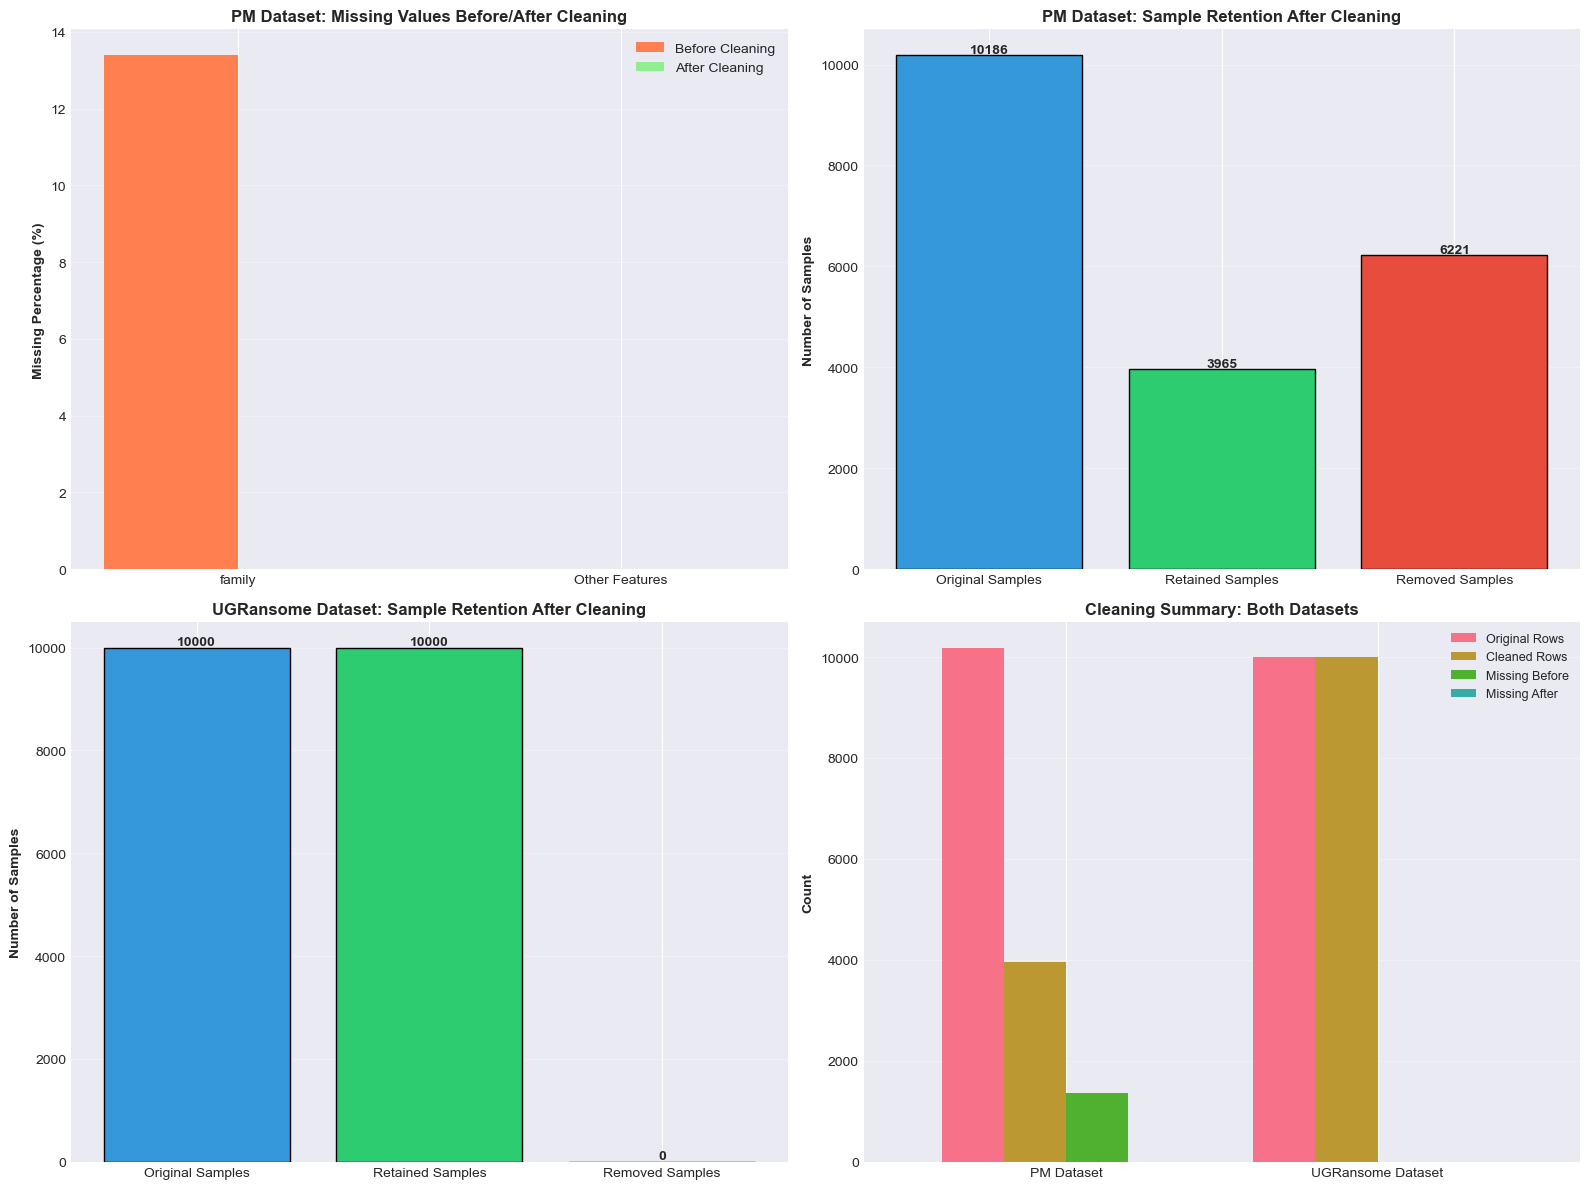


✓ Visualization saved as 'Data_Cleaning_Impact_Visualization.png'

SAVING CLEANED DATASETS

✓ Cleaned datasets saved:
  - PM_cleaned.csv
  - UGRansome_cleaned.csv

SECTIONS 2.1.2 & 2.1.3 COMPLETE

Summary:
  PM Dataset: 10186 → 3965 samples (38.93% retained)
  UGRansome Dataset: 10000 → 10000 samples (100.00% retained)
  Total missing values eliminated: 1364


In [13]:
"""
Section 2.1.2: Strategy and Justification of Handling Inconsistencies
Section 2.1.3: Code Summary and Cleaned Dataset Overview

"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Load the datasets
print("="*80)
print("LOADING ORIGINAL DATASETS")
print("="*80)

pm_df = pd.read_csv('PM.csv')
ugransome_df = pd.read_csv('UGRansome.csv')

print(f"\nOriginal PM Dataset Shape: {pm_df.shape}")
print(f"Original UGRansome Dataset Shape: {ugransome_df.shape}")

# ============================================================================
# SECTION 2.1.2: STRATEGY AND JUSTIFICATION OF HANDLING INCONSISTENCIES
# ============================================================================

print("\n" + "="*80)
print("SECTION 2.1.2: DATA CLEANING STRATEGY")
print("="*80)

# ------------------------------------------------------------------------
# STEP 1: Check for Duplicate Records
# ------------------------------------------------------------------------
print("\n[STEP 1] DUPLICATE DETECTION")
print("-" * 80)

def check_duplicates(df, dataset_name):
    """Check for duplicate rows in the dataset"""
    total_duplicates = df.duplicated().sum()
    duplicate_percentage = (total_duplicates / len(df)) * 100
    
    print(f"\n{dataset_name}:")
    print(f"  Total duplicate rows: {total_duplicates}")
    print(f"  Duplicate percentage: {duplicate_percentage:.2f}%")
    
    if total_duplicates > 0:
        print(f"  ⚠️  Action: Duplicates will be removed")
    else:
        print(f"  ✓ No duplicates found")
    
    return total_duplicates

pm_duplicates = check_duplicates(pm_df, "PM Dataset")
ugr_duplicates = check_duplicates(ugransome_df, "UGRansome Dataset")

# ------------------------------------------------------------------------
# STEP 2: Handle Missing Values - PM 'family' Feature
# ------------------------------------------------------------------------
print("\n\n[STEP 2] MISSING VALUES HANDLING STRATEGY")
print("-" * 80)

print("\nPM Dataset - 'family' feature (13.39% missing):")
print("\nStrategy Options Evaluated:")
print("  1. Deletion: Remove 1,364 samples (13.39% data loss)")
print("  2. Mode Imputation: Fill with most frequent family")
print("  3. Create 'Unknown' Category: Preserve samples, label as 'Unknown'")
print("  4. Predictive Imputation: Use other features to predict family")

print("\n✓ SELECTED STRATEGY: Create 'Unknown' Category")
print("\nJustification:")
print("  • Preserves all 10,186 samples for LLM training")
print("  • Maintains memory privilege patterns (r, rw, rx, etc.) which are complete")
print("  • 'Unknown' category is interpretable for XAI (SHAP/LIME)")
print("  • Avoids bias from imputing incorrect family labels")
print("  • Aligns with cybersecurity practice (unknown malware variants)")

# ------------------------------------------------------------------------
# STEP 3: Check for Data Inconsistencies
# ------------------------------------------------------------------------
print("\n\n[STEP 3] DATA INCONSISTENCY CHECK")
print("-" * 80)

def check_inconsistencies(df, dataset_name):
    """Check for various data inconsistencies"""
    print(f"\n{dataset_name}:")
    
    issues = []
    
    # Check for negative values in numerical columns (where inappropriate)
    for col in df.select_dtypes(include=[np.number]).columns:
        negative_count = (df[col] < 0).sum()
        if negative_count > 0:
            issues.append(f"  ⚠️  '{col}': {negative_count} negative values found")
    
    # Check for extreme outliers (beyond 3 standard deviations)
    outlier_summary = {}
    for col in df.select_dtypes(include=[np.number]).columns:
        z_scores = np.abs(stats.zscore(df[col].dropna()))
        outliers = (z_scores > 3).sum()
        if outliers > 0:
            outlier_summary[col] = outliers
    
    if outlier_summary:
        print(f"  Outliers detected (|z-score| > 3):")
        for col, count in outlier_summary.items():
            print(f"    - {col}: {count} outliers ({(count/len(df)*100):.2f}%)")
    
    # Check for whitespace in string columns
    for col in df.select_dtypes(include=['object']).columns:
        whitespace = df[col].astype(str).str.strip() != df[col].astype(str)
        if whitespace.sum() > 0:
            issues.append(f"  ⚠️  '{col}': {whitespace.sum()} entries with leading/trailing whitespace")
    
    # Check for mixed case issues
    for col in df.select_dtypes(include=['object']).columns:
        unique_lower = df[col].dropna().str.lower().nunique()
        unique_original = df[col].dropna().nunique()
        if unique_lower < unique_original:
            issues.append(f"  ⚠️  '{col}': Mixed case detected (may need standardization)")
    
    if not issues and not outlier_summary:
        print("  ✓ No critical inconsistencies detected")
    else:
        for issue in issues:
            print(issue)
    
    return outlier_summary

pm_outliers = check_inconsistencies(pm_df, "PM Dataset")
ugr_outliers = check_inconsistencies(ugransome_df, "UGRansome Dataset")

print("\n✓ OUTLIER HANDLING STRATEGY:")
print("  • Outliers in cybersecurity data often represent critical anomalies")
print("  • Outliers will be RETAINED as they may indicate ransomware behavior")
print("  • Data normalization (Section 2.4) will handle scale differences")

# ------------------------------------------------------------------------
# STEP 4: Check Target Variable Distribution (Class Imbalance)
# ------------------------------------------------------------------------
print("\n\n[STEP 4] CLASS BALANCE ANALYSIS")
print("-" * 80)

def analyze_class_balance(df, target_col, dataset_name):
    """Analyze class distribution in target variable"""
    print(f"\n{dataset_name} - Target: '{target_col}'")
    class_counts = df[target_col].value_counts()
    class_percentages = df[target_col].value_counts(normalize=True) * 100
    
    print("\nClass Distribution:")
    for cls, count in class_counts.items():
        pct = class_percentages[cls]
        print(f"  {cls}: {count} samples ({pct:.2f}%)")
    
    # Calculate imbalance ratio
    if len(class_counts) == 2:
        imbalance_ratio = class_counts.max() / class_counts.min()
        print(f"\nImbalance Ratio: {imbalance_ratio:.2f}:1")
        
        if imbalance_ratio > 1.5:
            print(f"  ⚠️  Class imbalance detected")
            print(f"  Strategy: Address during model training (class weights, SMOTE, etc.)")
        else:
            print(f"  ✓ Classes are relatively balanced")
    
    return class_counts

pm_balance = analyze_class_balance(pm_df, 'label', "PM Dataset")
ugr_balance = analyze_class_balance(ugransome_df, 'prediction', "UGRansome Dataset")

# ============================================================================
# APPLY CLEANING TRANSFORMATIONS
# ============================================================================

print("\n\n" + "="*80)
print("APPLYING DATA CLEANING TRANSFORMATIONS")
print("="*80)

# Create copies for cleaning
pm_cleaned = pm_df.copy()
ugransome_cleaned = ugransome_df.copy()

# 1. Remove duplicates
print("\n[1] Removing duplicates...")
pm_cleaned = pm_cleaned.drop_duplicates()
ugransome_cleaned = ugransome_cleaned.drop_duplicates()
print(f"  PM: {len(pm_df) - len(pm_cleaned)} duplicates removed")
print(f"  UGRansome: {len(ugransome_df) - len(ugransome_cleaned)} duplicates removed")

# 2. Handle missing values in PM 'family'
print("\n[2] Handling missing values...")
pm_cleaned['family'] = pm_cleaned['family'].fillna('Unknown')
print(f"  PM 'family': {pm_df['family'].isnull().sum()} missing values filled with 'Unknown'")
print(f"  UGRansome: No missing values to handle")

# 3. Strip whitespace from string columns
print("\n[3] Cleaning string data (removing whitespace)...")
for col in pm_cleaned.select_dtypes(include=['object']).columns:
    pm_cleaned[col] = pm_cleaned[col].astype(str).str.strip()

for col in ugransome_cleaned.select_dtypes(include=['object']).columns:
    ugransome_cleaned[col] = ugransome_cleaned[col].astype(str).str.strip()
print("  ✓ Whitespace removed from all string columns")

# 4. Standardize string case (optional - for consistency)
print("\n[4] Standardizing categorical values...")
# Keep original case for features but ensure consistency
for col in ['category', 'label']:
    if col in pm_cleaned.columns:
        pm_cleaned[col] = pm_cleaned[col].str.title()

print("  ✓ Categorical values standardized")

# ============================================================================
# SECTION 2.1.3: CLEANED DATASET OVERVIEW
# ============================================================================

print("\n\n" + "="*80)
print("SECTION 2.1.3: CLEANED DATASET OVERVIEW")
print("="*80)

def generate_cleaned_overview(df_original, df_cleaned, dataset_name):
    """Generate comprehensive overview of cleaned dataset"""
    print(f"\n{dataset_name}")
    print("-" * 80)
    
    print("\nShape Comparison:")
    print(f"  Original: {df_original.shape}")
    print(f"  Cleaned:  {df_cleaned.shape}")
    print(f"  Rows removed: {len(df_original) - len(df_cleaned)}")
    print(f"  Retention rate: {(len(df_cleaned)/len(df_original)*100):.2f}%")
    
    print("\nData Quality Metrics:")
    print(f"  Total missing values: {df_cleaned.isnull().sum().sum()}")
    print(f"  Missing percentage: {(df_cleaned.isnull().sum().sum()/(df_cleaned.shape[0]*df_cleaned.shape[1])*100):.2f}%")
    print(f"  Duplicate rows: {df_cleaned.duplicated().sum()}")
    
    print("\nFeature Summary:")
    print(f"  Total features: {df_cleaned.shape[1]}")
    print(f"  Numerical features: {len(df_cleaned.select_dtypes(include=[np.number]).columns)}")
    print(f"  Categorical features: {len(df_cleaned.select_dtypes(include=['object']).columns)}")
    
    print("\nSample of Cleaned Data (First 3 rows):")
    print(df_cleaned.head(3).to_string())
    
    return df_cleaned

print("\n" + "="*50)
pm_cleaned_final = generate_cleaned_overview(pm_df, pm_cleaned, "PM DATASET")

print("\n\n" + "="*50)
ugransome_cleaned_final = generate_cleaned_overview(ugransome_df, ugransome_cleaned, "UGRANSOME DATASET")

# ============================================================================
# VISUALIZATION: BEFORE/AFTER CLEANING
# ============================================================================

print("\n\n" + "="*80)
print("GENERATING CLEANING IMPACT VISUALIZATIONS")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# PM Dataset - Missing Values Before/After
ax1 = axes[0, 0]
missing_before_pm = pd.Series({
    'family': (pm_df['family'].isnull().sum() / len(pm_df)) * 100,
    'Other Features': 0
})
missing_after_pm = pd.Series({
    'family': (pm_cleaned['family'].isnull().sum() / len(pm_cleaned)) * 100,
    'Other Features': 0
})

x = np.arange(len(missing_before_pm))
width = 0.35
ax1.bar(x - width/2, missing_before_pm, width, label='Before Cleaning', color='coral')
ax1.bar(x + width/2, missing_after_pm, width, label='After Cleaning', color='lightgreen')
ax1.set_ylabel('Missing Percentage (%)', fontweight='bold')
ax1.set_title('PM Dataset: Missing Values Before/After Cleaning', fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(missing_before_pm.index)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# PM Dataset - Sample Retention
ax2 = axes[0, 1]
retention_pm = pd.Series({
    'Original Samples': len(pm_df),
    'Retained Samples': len(pm_cleaned),
    'Removed Samples': len(pm_df) - len(pm_cleaned)
})
colors_pm = ['#3498db', '#2ecc71', '#e74c3c']
ax2.bar(retention_pm.index, retention_pm.values, color=colors_pm, edgecolor='black')
ax2.set_ylabel('Number of Samples', fontweight='bold')
ax2.set_title('PM Dataset: Sample Retention After Cleaning', fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
for i, v in enumerate(retention_pm.values):
    ax2.text(i, v + 50, str(v), ha='center', fontweight='bold')

# UGRansome Dataset - Sample Retention
ax3 = axes[1, 0]
retention_ugr = pd.Series({
    'Original Samples': len(ugransome_df),
    'Retained Samples': len(ugransome_cleaned),
    'Removed Samples': len(ugransome_df) - len(ugransome_cleaned)
})
ax3.bar(retention_ugr.index, retention_ugr.values, color=colors_pm, edgecolor='black')
ax3.set_ylabel('Number of Samples', fontweight='bold')
ax3.set_title('UGRansome Dataset: Sample Retention After Cleaning', fontweight='bold')
ax3.grid(axis='y', alpha=0.3)
for i, v in enumerate(retention_ugr.values):
    ax3.text(i, v + 50, str(v), ha='center', fontweight='bold')

# Summary Statistics Comparison
ax4 = axes[1, 1]
summary_data = pd.DataFrame({
    'PM Dataset': [
        len(pm_df), 
        len(pm_cleaned),
        pm_df.isnull().sum().sum(),
        pm_cleaned.isnull().sum().sum()
    ],
    'UGRansome Dataset': [
        len(ugransome_df),
        len(ugransome_cleaned),
        ugransome_df.isnull().sum().sum(),
        ugransome_cleaned.isnull().sum().sum()
    ]
}, index=['Original Rows', 'Cleaned Rows', 'Missing Before', 'Missing After'])

summary_data.T.plot(kind='bar', ax=ax4, width=0.8)
ax4.set_ylabel('Count', fontweight='bold')
ax4.set_title('Cleaning Summary: Both Datasets', fontweight='bold')
ax4.legend(loc='upper right', fontsize=9)
ax4.grid(axis='y', alpha=0.3)
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.savefig('Data_Cleaning_Impact_Visualization.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Visualization saved as 'Data_Cleaning_Impact_Visualization.png'")

# ============================================================================
# SAVE CLEANED DATASETS
# ============================================================================

print("\n" + "="*80)
print("SAVING CLEANED DATASETS")
print("="*80)

pm_cleaned.to_csv('PM_cleaned.csv', index=False)
ugransome_cleaned.to_csv('UGRansome_cleaned.csv', index=False)

print("\n✓ Cleaned datasets saved:")
print("  - PM_cleaned.csv")
print("  - UGRansome_cleaned.csv")

print("\n" + "="*80)
print("SECTIONS 2.1.2 & 2.1.3 COMPLETE")
print("="*80)
print("\nSummary:")
print(f"  PM Dataset: {len(pm_df)} → {len(pm_cleaned)} samples ({((len(pm_cleaned)/len(pm_df))*100):.2f}% retained)")
print(f"  UGRansome Dataset: {len(ugransome_df)} → {len(ugransome_cleaned)} samples ({((len(ugransome_cleaned)/len(ugransome_df))*100):.2f}% retained)")
print(f"  Total missing values eliminated: {pm_df.isnull().sum().sum() + ugransome_df.isnull().sum().sum()}")

SECTION 2.1.4: FEATURE CATEGORIZATION

PM Cleaned Dataset Shape: (3965, 9)
UGRansome Cleaned Dataset Shape: (10000, 14)

PM DATASET - FEATURE CATEGORIZATION

Total Features: 9
Numerical Features: 6
Categorical Features: 2
Target Variable: 1

--------------------------------------------------------------------------------
DETAILED FEATURE CATEGORIZATION TABLE
--------------------------------------------------------------------------------


NUMERICAL FEATURES (6):
--------------------------------------------------------------------------------

r:
  Data Type: int64
  Unique Values: 245
  Missing: 0
  Min: 0.00, Max: 512.00, Mean: 137.82, Std: 100.60
  Sample: 69, 120, 120

rw:
  Data Type: int64
  Unique Values: 399
  Missing: 0
  Min: 1.00, Max: 7217.00, Mean: 185.45, Std: 278.50
  Sample: 71, 102, 101

rx:
  Data Type: int64
  Unique Values: 118
  Missing: 0
  Min: 0.00, Max: 169.00, Mean: 50.84, Std: 35.18
  Sample: 26, 50, 50

rwc:
  Data Type: int64
  Unique Values: 119
  Missing:

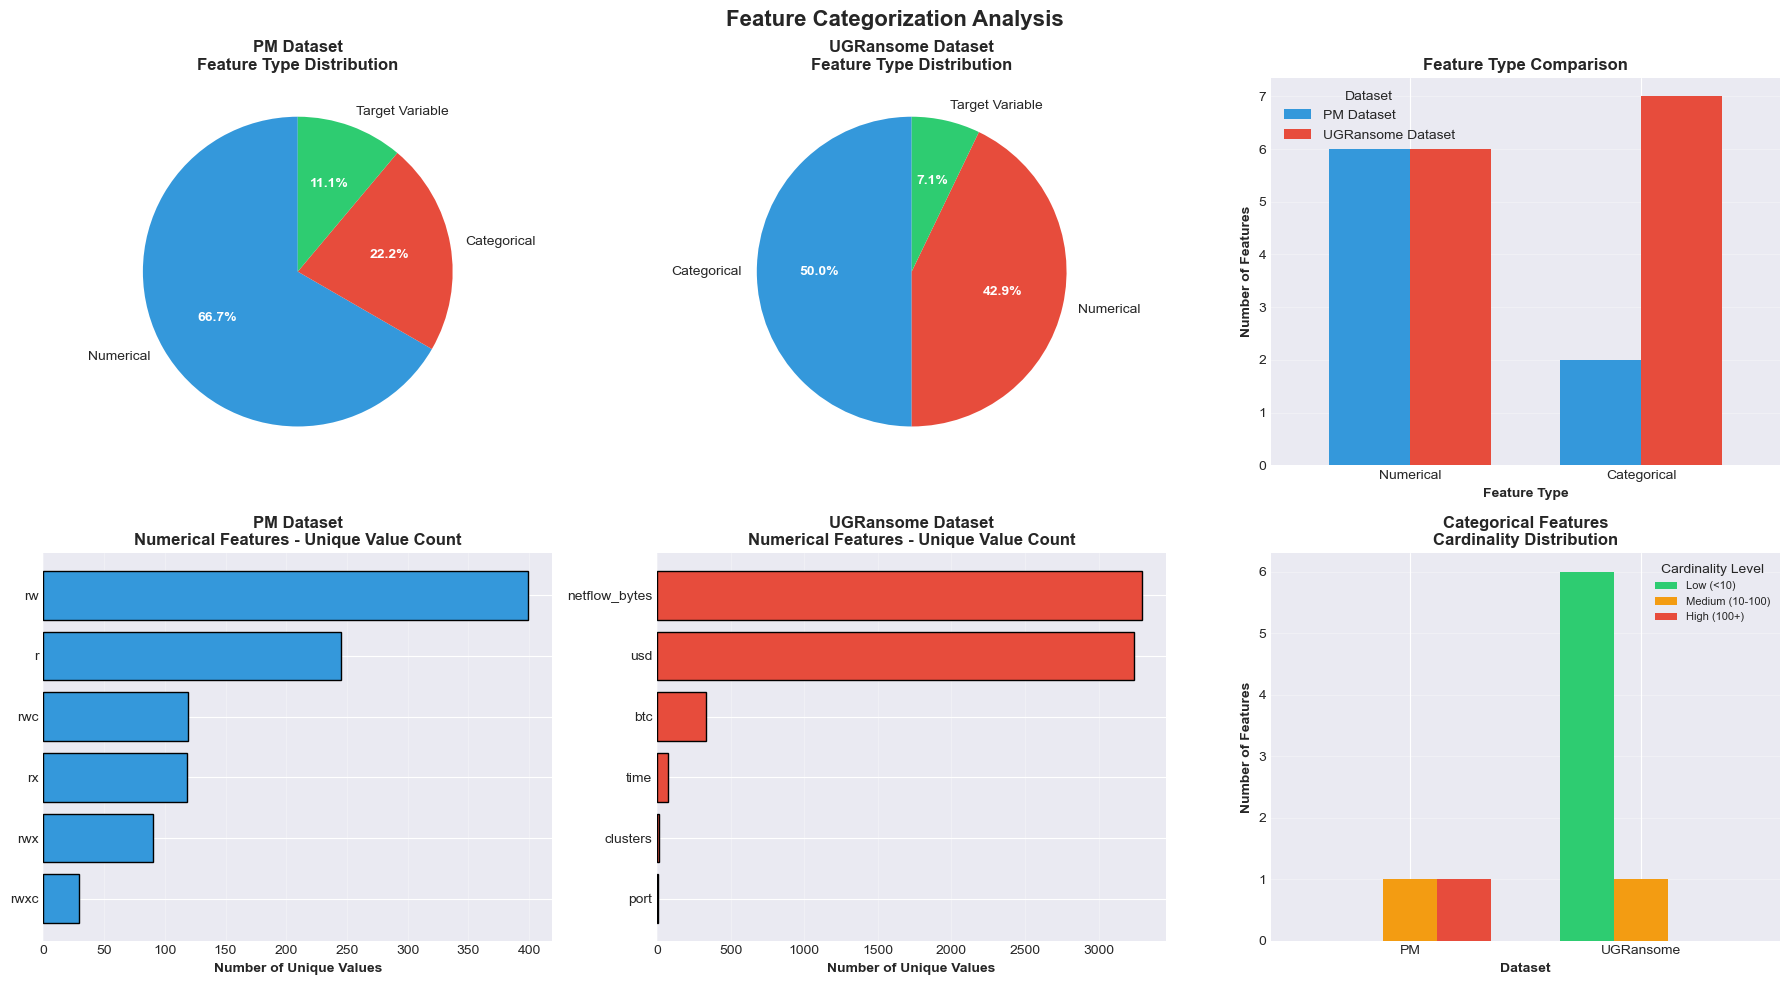


✓ Visualization saved as 'Feature_Categorization_Analysis.png'

EXPORTING CATEGORIZATION TABLES

✓ Feature categorization tables saved:
  - PM_Feature_Categorization.csv
  - UGRansome_Feature_Categorization.csv


SUMMARY FOR LLM PREPROCESSING

PM DATASET:
----------------------------------------
Features ready for tokenization: 6
Features requiring encoding: 2
Target variable: label (Binary: Ransomware/Benign)

UGRANSOME DATASET:
----------------------------------------
Features ready for tokenization: 6
Features requiring encoding: 7
Target variable: prediction (Binary: Ransomware/Benign)

SECTION 2.1.4 COMPLETE


In [16]:
"""
Section 2.1.4: Feature Categorization Table (Numerical vs. Categorical)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned datasets
print("="*80)
print("SECTION 2.1.4: FEATURE CATEGORIZATION")
print("="*80)

pm_cleaned = pd.read_csv('PM_cleaned.csv')
ugransome_cleaned = pd.read_csv('UGRansome_cleaned.csv')

print(f"\nPM Cleaned Dataset Shape: {pm_cleaned.shape}")
print(f"UGRansome Cleaned Dataset Shape: {ugransome_cleaned.shape}")

# ============================================================================
# FEATURE CATEGORIZATION ANALYSIS
# ============================================================================

def categorize_features(df, dataset_name, target_col):
    """
    Categorize features into numerical and categorical with detailed statistics
    """
    print(f"\n{'='*80}")
    print(f"{dataset_name.upper()} - FEATURE CATEGORIZATION")
    print(f"{'='*80}\n")
    
    categorization = []
    
    for col in df.columns:
        # Basic information
        dtype = df[col].dtype
        unique_count = df[col].nunique()
        missing_count = df[col].isnull().sum()
        
        # Determine category type
        if col == target_col:
            category_type = "Target Variable"
            role = "Classification Label"
        elif dtype in ['int64', 'float64']:
            category_type = "Numerical"
            role = "Feature"
        else:
            category_type = "Categorical"
            role = "Feature"
        
        # Get sample values
        sample_values = df[col].dropna().head(3).tolist()
        sample_str = ', '.join([str(v) for v in sample_values])
        
        # Get statistics based on type
        if dtype in ['int64', 'float64']:
            min_val = df[col].min()
            max_val = df[col].max()
            mean_val = df[col].mean()
            std_val = df[col].std()
            stats = f"Min: {min_val:.2f}, Max: {max_val:.2f}, Mean: {mean_val:.2f}, Std: {std_val:.2f}"
        else:
            stats = f"Categories: {unique_count}"
        
        categorization.append({
            'Feature': col,
            'Type': category_type,
            'Role': role,
            'Data_Type': str(dtype),
            'Unique_Values': unique_count,
            'Missing': missing_count,
            'Statistics': stats,
            'Sample_Values': sample_str
        })
    
    # Create DataFrame
    cat_df = pd.DataFrame(categorization)
    
    # Print summary
    print(f"Total Features: {len(df.columns)}")
    print(f"Numerical Features: {len(cat_df[cat_df['Type'] == 'Numerical'])}")
    print(f"Categorical Features: {len(cat_df[cat_df['Type'] == 'Categorical'])}")
    print(f"Target Variable: 1")
    
    print("\n" + "-"*80)
    print("DETAILED FEATURE CATEGORIZATION TABLE")
    print("-"*80 + "\n")
    
    # Print by category type
    for cat_type in ['Numerical', 'Categorical', 'Target Variable']:
        subset = cat_df[cat_df['Type'] == cat_type]
        if len(subset) > 0:
            print(f"\n{cat_type.upper()} FEATURES ({len(subset)}):")
            print("-" * 80)
            for idx, row in subset.iterrows():
                print(f"\n{row['Feature']}:")
                print(f"  Data Type: {row['Data_Type']}")
                print(f"  Unique Values: {row['Unique_Values']}")
                print(f"  Missing: {row['Missing']}")
                print(f"  {row['Statistics']}")
                print(f"  Sample: {row['Sample_Values']}")
    
    return cat_df

# Analyze both datasets
pm_categorization = categorize_features(pm_cleaned, "PM Dataset", "label")
ugr_categorization = categorize_features(ugransome_cleaned, "UGRansome Dataset", "prediction")

# ============================================================================
# CREATE SUMMARY TABLES
# ============================================================================

print("\n\n" + "="*80)
print("FEATURE CATEGORIZATION SUMMARY TABLES")
print("="*80)

def create_summary_table(cat_df, dataset_name):
    """Create a clean summary table for the report"""
    print(f"\n{dataset_name} - Summary Table:")
    print("-" * 80)
    
    summary = cat_df[['Feature', 'Type', 'Data_Type', 'Unique_Values', 'Statistics']].copy()
    print(summary.to_string(index=False))
    
    return summary

pm_summary = create_summary_table(pm_categorization, "PM DATASET")
ugr_summary = create_summary_table(ugr_categorization, "UGRANSOME DATASET")

# ============================================================================
# VISUALIZATION: FEATURE TYPE DISTRIBUTION
# ============================================================================

print("\n\n" + "="*80)
print("GENERATING FEATURE CATEGORIZATION VISUALIZATIONS")
print("="*80)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Feature Categorization Analysis', fontsize=16, fontweight='bold')

# PM Dataset - Feature Type Distribution
ax1 = axes[0, 0]
pm_type_counts = pm_categorization['Type'].value_counts()
colors = ['#3498db', '#e74c3c', '#2ecc71']
wedges, texts, autotexts = ax1.pie(pm_type_counts.values, labels=pm_type_counts.index, 
                                     autopct='%1.1f%%', startangle=90, colors=colors)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
ax1.set_title('PM Dataset\nFeature Type Distribution', fontweight='bold')

# UGRansome Dataset - Feature Type Distribution
ax2 = axes[0, 1]
ugr_type_counts = ugr_categorization['Type'].value_counts()
wedges, texts, autotexts = ax2.pie(ugr_type_counts.values, labels=ugr_type_counts.index,
                                     autopct='%1.1f%%', startangle=90, colors=colors)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
ax2.set_title('UGRansome Dataset\nFeature Type Distribution', fontweight='bold')

# Feature Count Comparison
ax3 = axes[0, 2]
comparison_data = pd.DataFrame({
    'PM Dataset': [
        len(pm_categorization[pm_categorization['Type'] == 'Numerical']),
        len(pm_categorization[pm_categorization['Type'] == 'Categorical'])
    ],
    'UGRansome Dataset': [
        len(ugr_categorization[ugr_categorization['Type'] == 'Numerical']),
        len(ugr_categorization[ugr_categorization['Type'] == 'Categorical'])
    ]
}, index=['Numerical', 'Categorical'])

comparison_data.plot(kind='bar', ax=ax3, color=['#3498db', '#e74c3c'], width=0.7)
ax3.set_title('Feature Type Comparison', fontweight='bold')
ax3.set_ylabel('Number of Features', fontweight='bold')
ax3.set_xlabel('Feature Type', fontweight='bold')
ax3.legend(title='Dataset')
ax3.grid(axis='y', alpha=0.3)
plt.setp(ax3.get_xticklabels(), rotation=0)

# PM Dataset - Unique Values Distribution
ax4 = axes[1, 0]
pm_numerical = pm_categorization[pm_categorization['Type'] == 'Numerical']
if len(pm_numerical) > 0:
    pm_numerical_sorted = pm_numerical.sort_values('Unique_Values')
    ax4.barh(pm_numerical_sorted['Feature'], pm_numerical_sorted['Unique_Values'], 
             color='#3498db', edgecolor='black')
    ax4.set_xlabel('Number of Unique Values', fontweight='bold')
    ax4.set_title('PM Dataset\nNumerical Features - Unique Value Count', fontweight='bold')
    ax4.grid(axis='x', alpha=0.3)

# UGRansome Dataset - Unique Values Distribution (Numerical)
ax5 = axes[1, 1]
ugr_numerical = ugr_categorization[ugr_categorization['Type'] == 'Numerical']
if len(ugr_numerical) > 0:
    ugr_numerical_sorted = ugr_numerical.sort_values('Unique_Values')
    ax5.barh(ugr_numerical_sorted['Feature'], ugr_numerical_sorted['Unique_Values'],
             color='#e74c3c', edgecolor='black')
    ax5.set_xlabel('Number of Unique Values', fontweight='bold')
    ax5.set_title('UGRansome Dataset\nNumerical Features - Unique Value Count', fontweight='bold')
    ax5.grid(axis='x', alpha=0.3)

# Categorical Features - Cardinality Comparison
ax6 = axes[1, 2]
pm_categorical = pm_categorization[pm_categorization['Type'] == 'Categorical']
ugr_categorical = ugr_categorization[ugr_categorization['Type'] == 'Categorical']

cardinality_data = {
    'Low (<10)': [
        len(pm_categorical[pm_categorical['Unique_Values'] < 10]),
        len(ugr_categorical[ugr_categorical['Unique_Values'] < 10])
    ],
    'Medium (10-100)': [
        len(pm_categorical[(pm_categorical['Unique_Values'] >= 10) & 
                          (pm_categorical['Unique_Values'] < 100)]),
        len(ugr_categorical[(ugr_categorical['Unique_Values'] >= 10) & 
                           (ugr_categorical['Unique_Values'] < 100)])
    ],
    'High (100+)': [
        len(pm_categorical[pm_categorical['Unique_Values'] >= 100]),
        len(ugr_categorical[ugr_categorical['Unique_Values'] >= 100])
    ]
}

cardinality_df = pd.DataFrame(cardinality_data, index=['PM', 'UGRansome'])
cardinality_df.plot(kind='bar', ax=ax6, color=['#2ecc71', '#f39c12', '#e74c3c'], width=0.7)
ax6.set_title('Categorical Features\nCardinality Distribution', fontweight='bold')
ax6.set_ylabel('Number of Features', fontweight='bold')
ax6.set_xlabel('Dataset', fontweight='bold')
ax6.legend(title='Cardinality Level', fontsize=8)
ax6.grid(axis='y', alpha=0.3)
plt.setp(ax6.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.savefig('Feature_Categorization_Analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Visualization saved as 'Feature_Categorization_Analysis.png'")

# ============================================================================
# EXPORT CATEGORIZATION TABLES
# ============================================================================

print("\n" + "="*80)
print("EXPORTING CATEGORIZATION TABLES")
print("="*80)

pm_categorization.to_csv('PM_Feature_Categorization.csv', index=False)
ugr_categorization.to_csv('UGRansome_Feature_Categorization.csv', index=False)

print("\n✓ Feature categorization tables saved:")
print("  - PM_Feature_Categorization.csv")
print("  - UGRansome_Feature_Categorization.csv")

# ============================================================================
# FINAL SUMMARY FOR LLM PREPROCESSING
# ============================================================================

print("\n\n" + "="*80)
print("SUMMARY FOR LLM PREPROCESSING")
print("="*80)

print("\nPM DATASET:")
print("-" * 40)
print(f"Features ready for tokenization: {len(pm_categorization[pm_categorization['Type'] == 'Numerical'])}")
print(f"Features requiring encoding: {len(pm_categorization[pm_categorization['Type'] == 'Categorical'])}")
print(f"Target variable: label (Binary: Ransomware/Benign)")

print("\nUGRANSOME DATASET:")
print("-" * 40)
print(f"Features ready for tokenization: {len(ugr_categorization[ugr_categorization['Type'] == 'Numerical'])}")
print(f"Features requiring encoding: {len(ugr_categorization[ugr_categorization['Type'] == 'Categorical'])}")
print(f"Target variable: prediction (Binary: Ransomware/Benign)")

print("\n" + "="*80)
print("SECTION 2.1.4 COMPLETE")
print("="*80)

SECTION 2.4: DATA VISUALIZATION & DISTRIBUTION ANALYSIS

Loading datasets...
PM Dataset Shape: (9, 8)
UGRansome Dataset Shape: (14, 8)
✓ Created Visualizations folder

VISUALIZATION 1: TARGET VARIABLE DISTRIBUTION


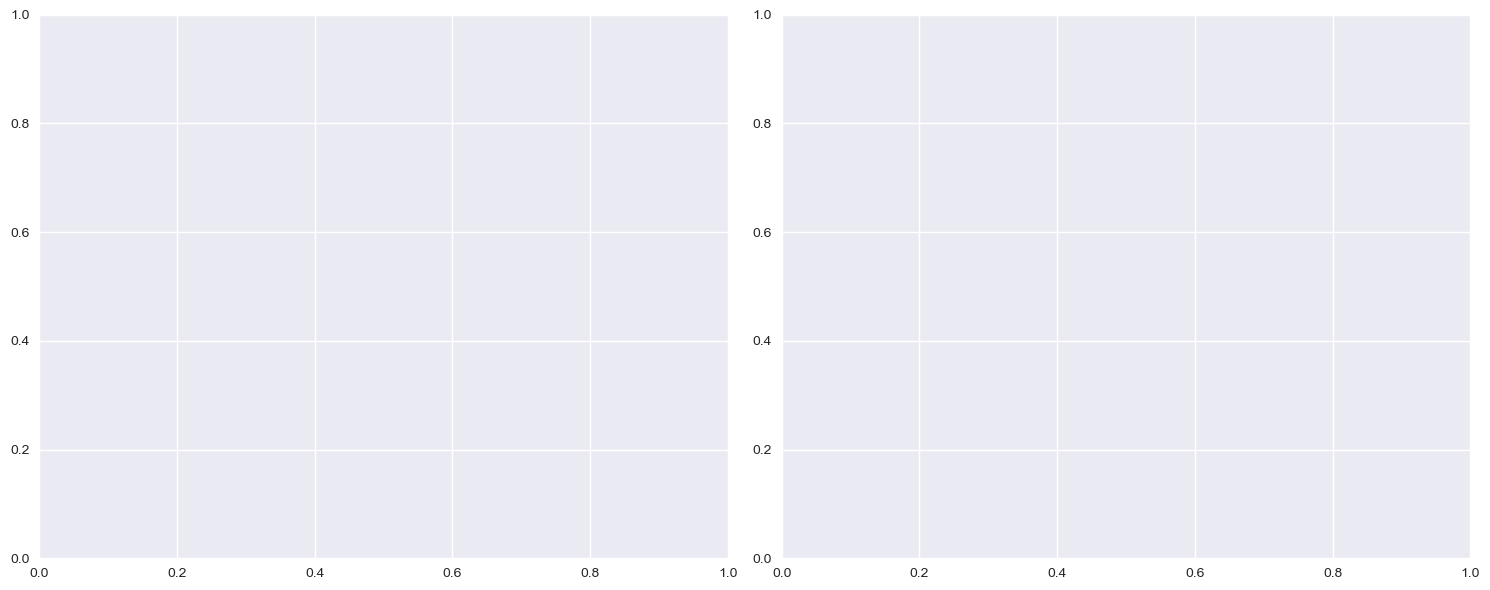

✓ Saved: Visualizations/1_Target_Variable_Distribution.png

VISUALIZATION 2: NUMERICAL FEATURES DISTRIBUTION
PM Numerical features: 2
UGRansome Numerical features: 2


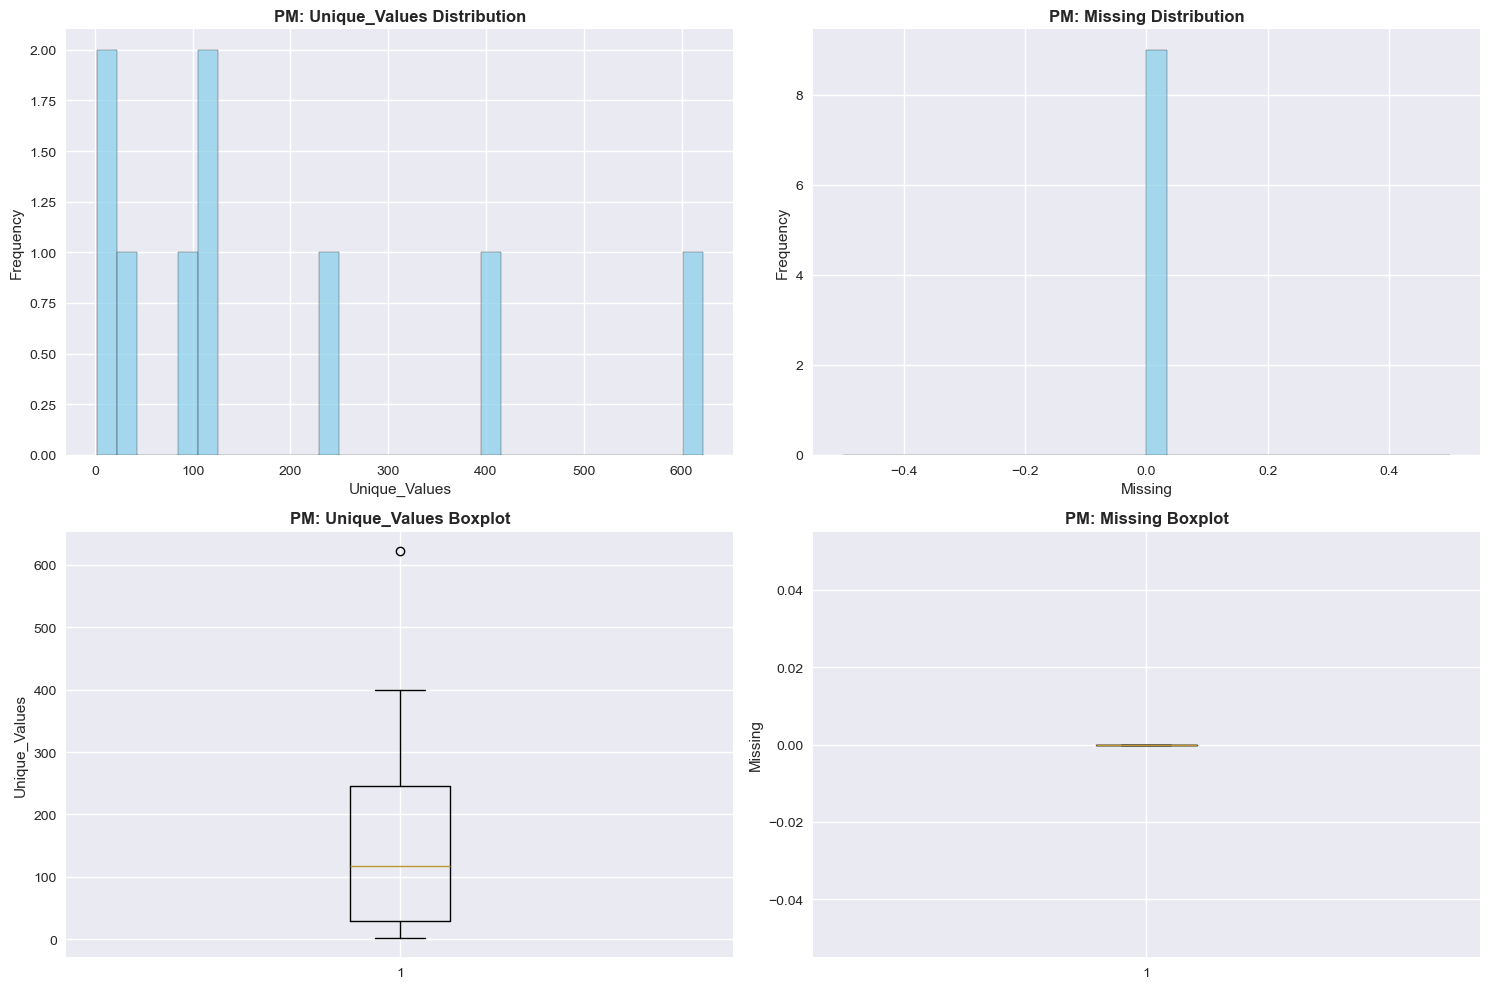

✓ Saved: Visualizations/2_PM_Numerical_Distribution.png


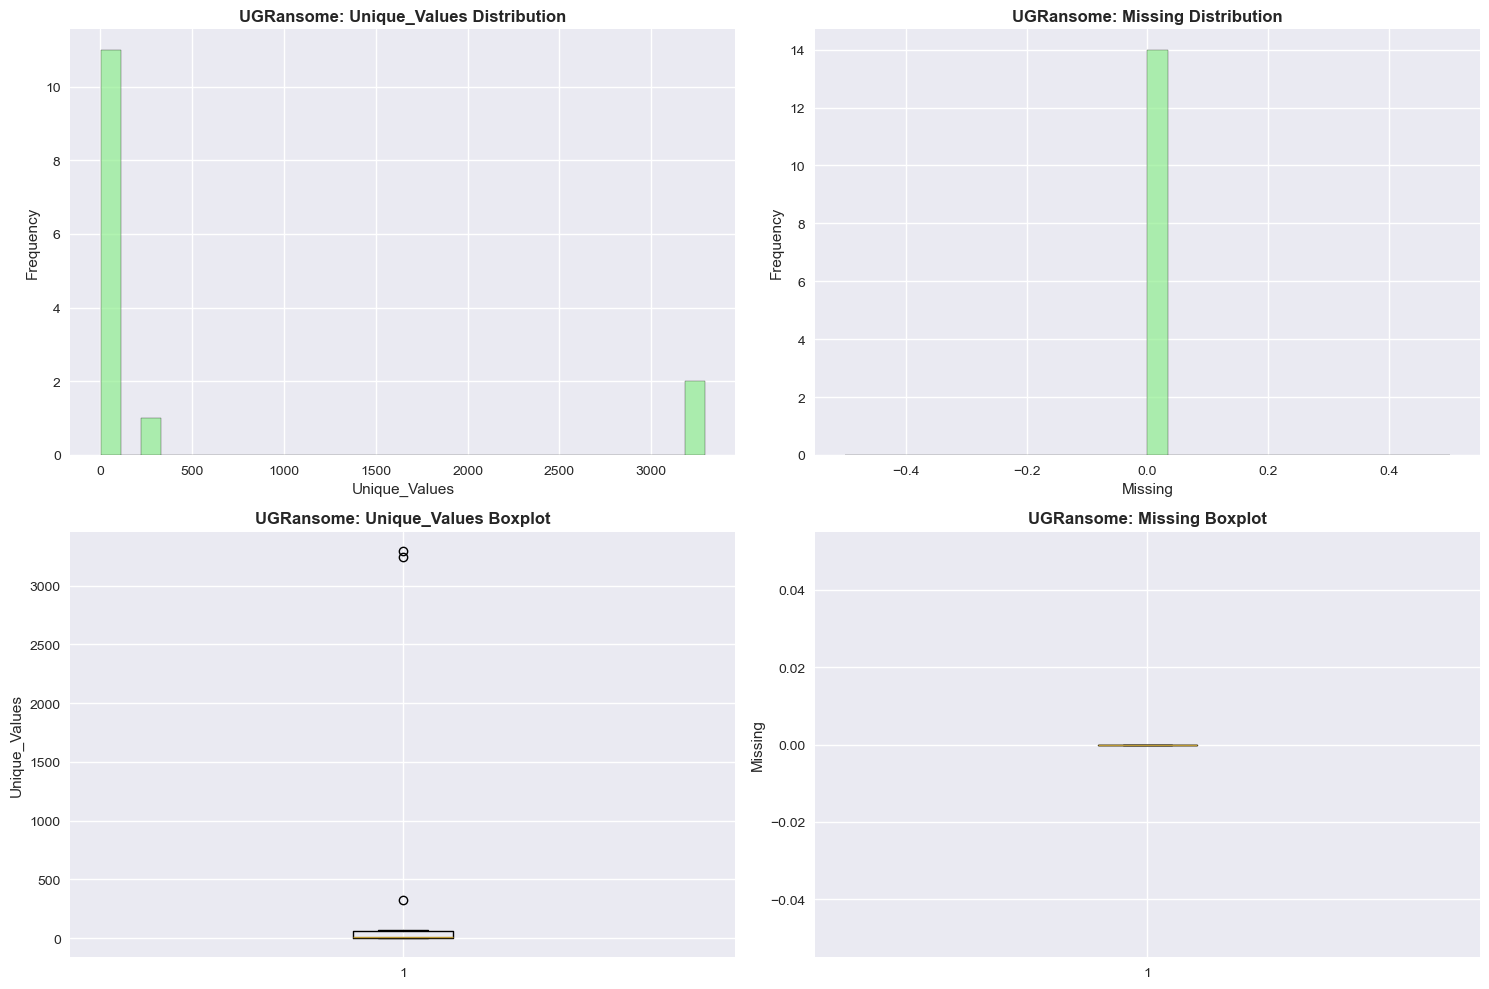

✓ Saved: Visualizations/2_UGRansome_Numerical_Distribution.png

VISUALIZATION 3: CORRELATION HEATMAP


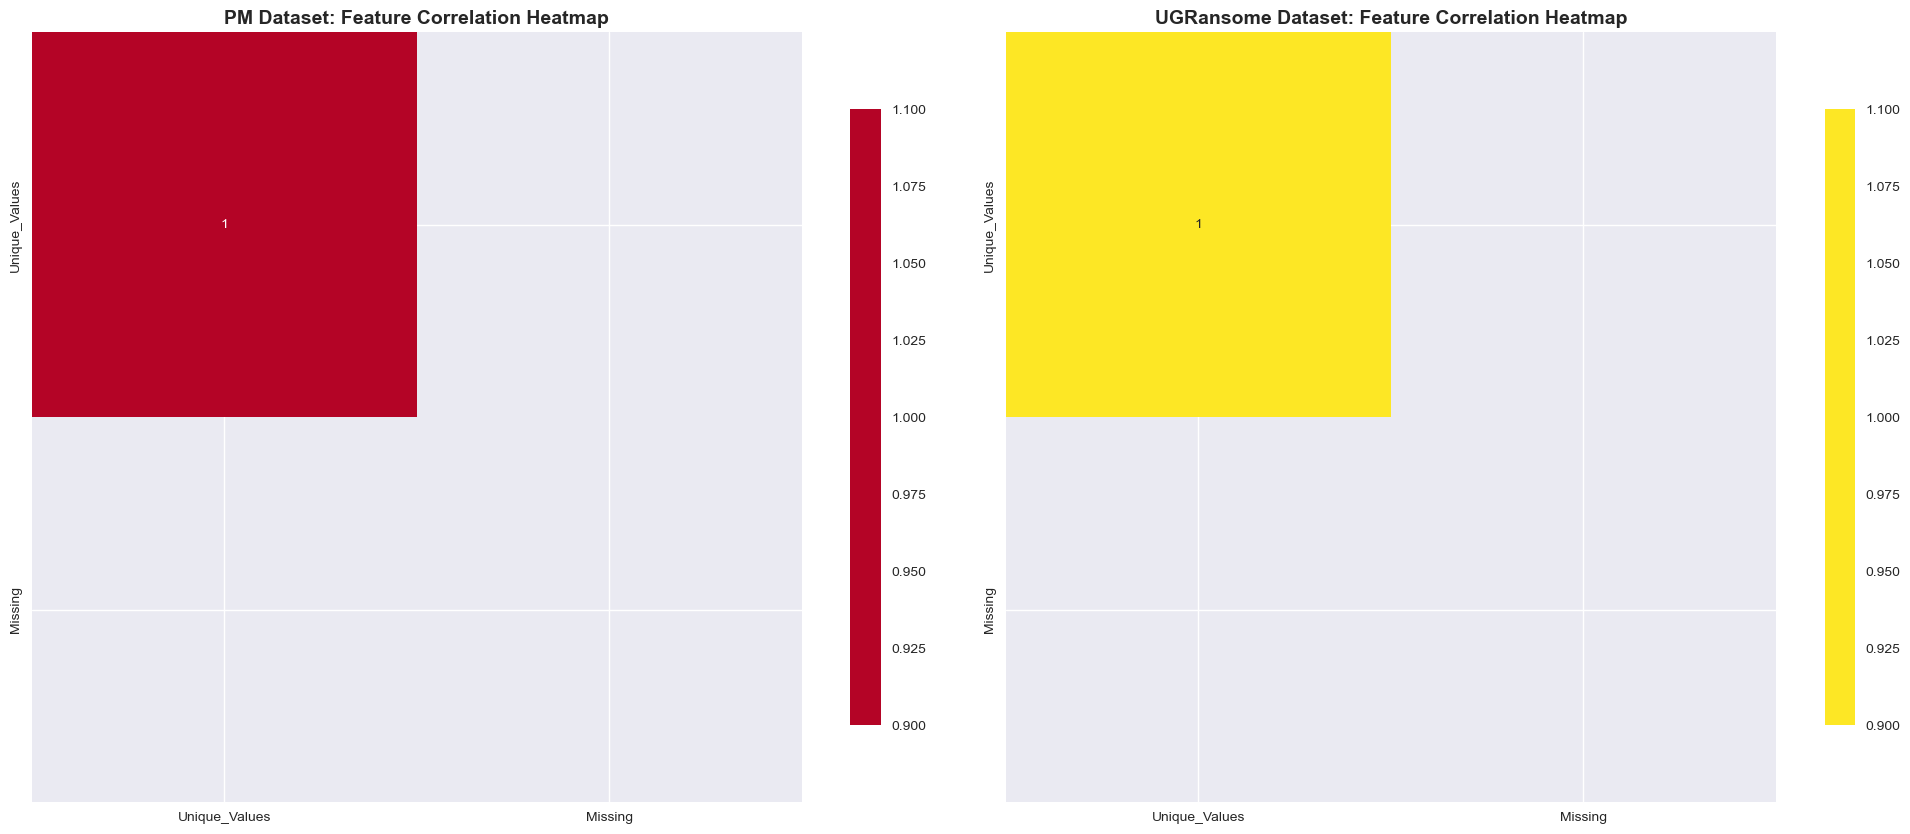

✓ Saved: Visualizations/3_Correlation_Heatmaps.png

VISUALIZATION 4: CATEGORICAL FEATURES ANALYSIS
PM Categorical features: 6
UGRansome Categorical features: 6


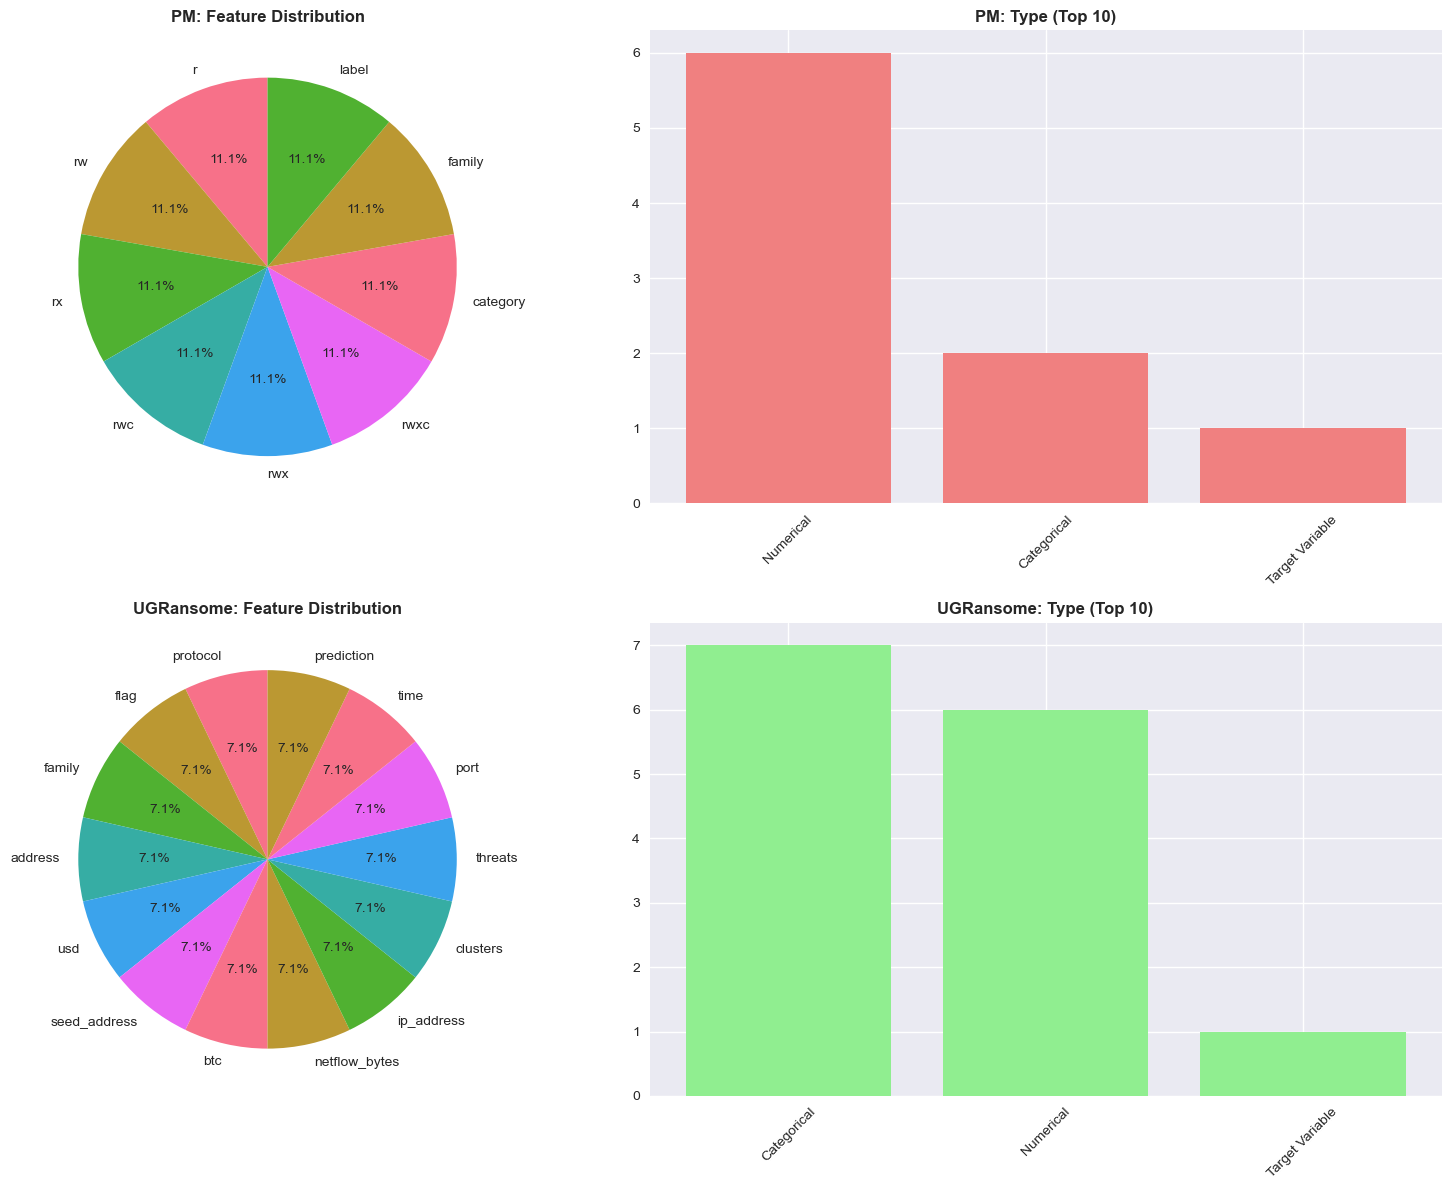

✓ Saved: Visualizations/4_Categorical_Features_Analysis.png

SKEWNESS ANALYSIS

PM Dataset Skewness Analysis:
----------------------------------------
  Unique_Values       :    1.181 (Highly skewed)
  Missing             :      nan (Highly skewed)

UGRansome Dataset Skewness Analysis:
----------------------------------------
  Unique_Values       :    2.020 (Highly skewed)
  Missing             :      nan (Highly skewed)

SKEWNESS VISUALIZATION


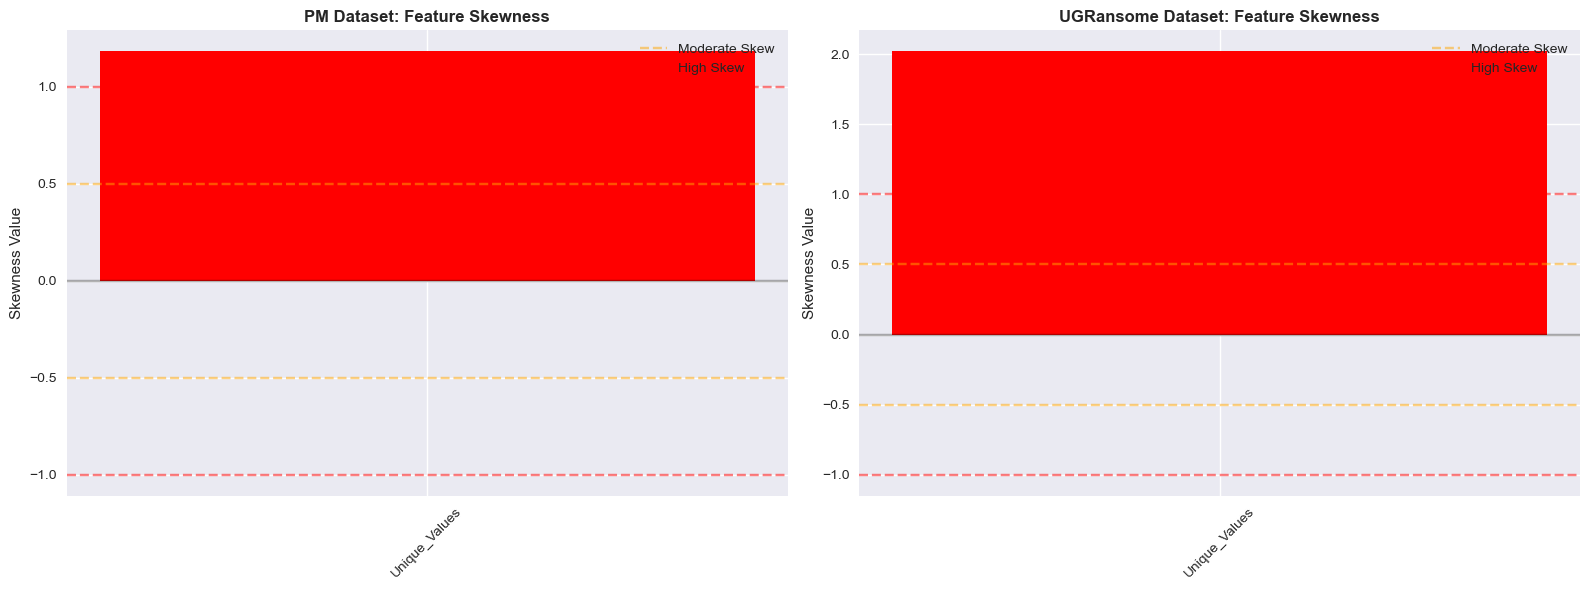

✓ Saved: Visualizations/5_Skewness_Analysis.png

SECTION 2.4 VISUALIZATIONS COMPLETE

✓ All visualizations saved in 'Visualizations' folder:
  1. Visualizations/1_Target_Variable_Distribution.png
  2. Visualizations/2_PM_Numerical_Distribution.png
  3. Visualizations/2_UGRansome_Numerical_Distribution.png
  4. Visualizations/3_Correlation_Heatmaps.png
  5. Visualizations/4_Categorical_Features_Analysis.png
  6. Visualizations/5_Skewness_Analysis.png

✓ Skewness analysis completed

Ready for normalization, transformation, and scaling steps.

VERIFYING SAVED FILES
Total visualization files saved: 6
  - Visualizations\1_Target_Variable_Distribution.png (57573 bytes)
  - Visualizations\2_PM_Numerical_Distribution.png (217799 bytes)
  - Visualizations\2_UGRansome_Numerical_Distribution.png (219252 bytes)
  - Visualizations\3_Correlation_Heatmaps.png (162706 bytes)
  - Visualizations\4_Categorical_Features_Analysis.png (470737 bytes)
  - Visualizations\5_Skewness_Analysis.png (151051 bytes)


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("=" * 80)
print("SECTION 2.4: DATA VISUALIZATION & DISTRIBUTION ANALYSIS")
print("=" * 80)

# Load the datasets
print("\nLoading datasets...")
pm_df = pd.read_csv('PM_Feature_Categorization.csv')
ugr_df = pd.read_csv('UGRansome_Feature_Categorization.csv')

print(f"PM Dataset Shape: {pm_df.shape}")
print(f"UGRansome Dataset Shape: {ugr_df.shape}")

# Create a folder for saving visuals
import os
if not os.path.exists('Visualizations'):
    os.makedirs('Visualizations')
    print("✓ Created Visualizations folder")

# ============================================================================
# VISUALIZATION 1: TARGET VARIABLE DISTRIBUTION (Bar Chart)
# ============================================================================

print("\n" + "="*50)
print("VISUALIZATION 1: TARGET VARIABLE DISTRIBUTION")
print("="*50)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# PM Dataset - Label Distribution
if 'label' in pm_df.columns:
    pm_label_counts = pm_df['label'].value_counts()
    axes[0].bar(pm_label_counts.index, pm_label_counts.values, color=['skyblue', 'lightcoral'])
    axes[0].set_title('PM Dataset: Label Distribution', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Label')
    axes[0].set_ylabel('Count')
    # Add value labels on bars
    for i, v in enumerate(pm_label_counts.values):
        axes[0].text(i, v + 0.01*v, str(v), ha='center', fontweight='bold')

# UGRansome Dataset - Prediction Distribution
if 'prediction' in ugr_df.columns:
    ugr_pred_counts = ugr_df['prediction'].value_counts()
    axes[1].bar(ugr_pred_counts.index, ugr_pred_counts.values, color=['lightgreen', 'orange'])
    axes[1].set_title('UGRansome Dataset: Prediction Distribution', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Prediction')
    axes[1].set_ylabel('Count')
    # Add value labels on bars
    for i, v in enumerate(ugr_pred_counts.values):
        axes[1].text(i, v + 0.01*v, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('Visualizations/1_Target_Variable_Distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: Visualizations/1_Target_Variable_Distribution.png")

# ============================================================================
# VISUALIZATION 2: NUMERICAL FEATURES DISTRIBUTION (Histogram & Boxplot)
# ============================================================================

print("\n" + "="*50)
print("VISUALIZATION 2: NUMERICAL FEATURES DISTRIBUTION")
print("="*50)

# Select numerical columns (excluding target variables)
pm_numerical = pm_df.select_dtypes(include=[np.number]).columns
ugr_numerical = ugr_df.select_dtypes(include=[np.number]).columns

# Remove target variables if they exist
pm_numerical = [col for col in pm_numerical if col not in ['label', 'prediction']]
ugr_numerical = [col for col in ugr_numerical if col not in ['label', 'prediction']]

print(f"PM Numerical features: {len(pm_numerical)}")
print(f"UGRansome Numerical features: {len(ugr_numerical)}")

# Plot distributions for first few numerical features
if len(pm_numerical) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # PM Dataset - First 2 numerical features
    for i, col in enumerate(pm_numerical[:2]):
        # Histogram
        axes[0, i].hist(pm_df[col].dropna(), bins=30, alpha=0.7, color='skyblue', edgecolor='black')
        axes[0, i].set_title(f'PM: {col} Distribution', fontweight='bold')
        axes[0, i].set_xlabel(col)
        axes[0, i].set_ylabel('Frequency')
        
        # Boxplot
        axes[1, i].boxplot(pm_df[col].dropna())
        axes[1, i].set_title(f'PM: {col} Boxplot', fontweight='bold')
        axes[1, i].set_ylabel(col)
    
    plt.tight_layout()
    plt.savefig('Visualizations/2_PM_Numerical_Distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ Saved: Visualizations/2_PM_Numerical_Distribution.png")

if len(ugr_numerical) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # UGRansome Dataset - First 2 numerical features
    for i, col in enumerate(ugr_numerical[:2]):
        # Histogram
        axes[0, i].hist(ugr_df[col].dropna(), bins=30, alpha=0.7, color='lightgreen', edgecolor='black')
        axes[0, i].set_title(f'UGRansome: {col} Distribution', fontweight='bold')
        axes[0, i].set_xlabel(col)
        axes[0, i].set_ylabel('Frequency')
        
        # Boxplot
        axes[1, i].boxplot(ugr_df[col].dropna())
        axes[1, i].set_title(f'UGRansome: {col} Boxplot', fontweight='bold')
        axes[1, i].set_ylabel(col)
    
    plt.tight_layout()
    plt.savefig('Visualizations/2_UGRansome_Numerical_Distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ Saved: Visualizations/2_UGRansome_Numerical_Distribution.png")

# ============================================================================
# VISUALIZATION 3: CORRELATION HEATMAP
# ============================================================================

print("\n" + "="*50)
print("VISUALIZATION 3: CORRELATION HEATMAP")
print("="*50)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# PM Dataset Correlation Heatmap
if len(pm_numerical) > 0:
    pm_corr = pm_df[pm_numerical].corr()
    sns.heatmap(pm_corr, annot=True, cmap='coolwarm', center=0, ax=axes[0], 
                square=True, cbar_kws={"shrink": .8})
    axes[0].set_title('PM Dataset: Feature Correlation Heatmap', fontsize=14, fontweight='bold')

# UGRansome Dataset Correlation Heatmap
if len(ugr_numerical) > 0:
    ugr_corr = ugr_df[ugr_numerical].corr()
    sns.heatmap(ugr_corr, annot=True, cmap='viridis', center=0, ax=axes[1],
                square=True, cbar_kws={"shrink": .8})
    axes[1].set_title('UGRansome Dataset: Feature Correlation Heatmap', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('Visualizations/3_Correlation_Heatmaps.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: Visualizations/3_Correlation_Heatmaps.png")

# ============================================================================
# VISUALIZATION 4: CATEGORICAL FEATURES ANALYSIS (Pie Chart & Count Plot)
# ============================================================================

print("\n" + "="*50)
print("VISUALIZATION 4: CATEGORICAL FEATURES ANALYSIS")
print("="*50)

# Get categorical columns
pm_categorical = pm_df.select_dtypes(include=['object']).columns
ugr_categorical = ugr_df.select_dtypes(include=['object']).columns

print(f"PM Categorical features: {len(pm_categorical)}")
print(f"UGRansome Categorical features: {len(ugr_categorical)}")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# PM Dataset - First categorical feature (Pie Chart)
if len(pm_categorical) > 0:
    pm_cat_counts = pm_df[pm_categorical[0]].value_counts()
    axes[0, 0].pie(pm_cat_counts.values, labels=pm_cat_counts.index, autopct='%1.1f%%', startangle=90)
    axes[0, 0].set_title(f'PM: {pm_categorical[0]} Distribution', fontweight='bold')

# PM Dataset - Second categorical feature (Count Plot)
if len(pm_categorical) > 1:
    pm_cat2_counts = pm_df[pm_categorical[1]].value_counts().head(10)  # Top 10 only
    axes[0, 1].bar(pm_cat2_counts.index, pm_cat2_counts.values, color='lightcoral')
    axes[0, 1].set_title(f'PM: {pm_categorical[1]} (Top 10)', fontweight='bold')
    axes[0, 1].tick_params(axis='x', rotation=45)

# UGRansome Dataset - First categorical feature (Pie Chart)
if len(ugr_categorical) > 0:
    ugr_cat_counts = ugr_df[ugr_categorical[0]].value_counts()
    axes[1, 0].pie(ugr_cat_counts.values, labels=ugr_cat_counts.index, autopct='%1.1f%%', startangle=90)
    axes[1, 0].set_title(f'UGRansome: {ugr_categorical[0]} Distribution', fontweight='bold')

# UGRansome Dataset - Second categorical feature (Count Plot)
if len(ugr_categorical) > 1:
    ugr_cat2_counts = ugr_df[ugr_categorical[1]].value_counts().head(10)  # Top 10 only
    axes[1, 1].bar(ugr_cat2_counts.index, ugr_cat2_counts.values, color='lightgreen')
    axes[1, 1].set_title(f'UGRansome: {ugr_categorical[1]} (Top 10)', fontweight='bold')
    axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('Visualizations/4_Categorical_Features_Analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: Visualizations/4_Categorical_Features_Analysis.png")

# ============================================================================
# ADDITIONAL ANALYSIS: SKEWNESS CALCULATION
# ============================================================================

print("\n" + "="*50)
print("SKEWNESS ANALYSIS")
print("="*50)

def analyze_skewness(df, dataset_name):
    """Analyze skewness of numerical features"""
    numerical_cols = df.select_dtypes(include=[np.number]).columns
    numerical_cols = [col for col in numerical_cols if col not in ['label', 'prediction']]
    
    print(f"\n{dataset_name} Skewness Analysis:")
    print("-" * 40)
    
    skewness_results = {}
    for col in numerical_cols:
        skew_val = stats.skew(df[col].dropna())
        skewness_results[col] = skew_val
        
        # Interpret skewness
        if abs(skew_val) < 0.5:
            skew_level = "Approximately symmetric"
        elif abs(skew_val) < 1:
            skew_level = "Moderately skewed"
        else:
            skew_level = "Highly skewed"
        
        print(f"  {col:20}: {skew_val:8.3f} ({skew_level})")
    
    return skewness_results

pm_skewness = analyze_skewness(pm_df, "PM Dataset")
ugr_skewness = analyze_skewness(ugr_df, "UGRansome Dataset")

# ============================================================================
# SKEWNESS VISUALIZATION
# ============================================================================

print("\n" + "="*50)
print("SKEWNESS VISUALIZATION")
print("="*50)

# Create skewness comparison plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PM Dataset Skewness
if pm_skewness:
    pm_skew_df = pd.DataFrame(list(pm_skewness.items()), columns=['Feature', 'Skewness'])
    colors = ['red' if abs(x) > 1 else 'orange' if abs(x) > 0.5 else 'green' for x in pm_skew_df['Skewness']]
    axes[0].bar(pm_skew_df['Feature'], pm_skew_df['Skewness'], color=colors)
    axes[0].set_title('PM Dataset: Feature Skewness', fontweight='bold')
    axes[0].set_ylabel('Skewness Value')
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].axhline(y=0, color='black', linestyle='-', alpha=0.3)
    axes[0].axhline(y=0.5, color='orange', linestyle='--', alpha=0.5, label='Moderate Skew')
    axes[0].axhline(y=-0.5, color='orange', linestyle='--', alpha=0.5)
    axes[0].axhline(y=1, color='red', linestyle='--', alpha=0.5, label='High Skew')
    axes[0].axhline(y=-1, color='red', linestyle='--', alpha=0.5)
    axes[0].legend()

# UGRansome Dataset Skewness
if ugr_skewness:
    ugr_skew_df = pd.DataFrame(list(ugr_skewness.items()), columns=['Feature', 'Skewness'])
    colors = ['red' if abs(x) > 1 else 'orange' if abs(x) > 0.5 else 'green' for x in ugr_skew_df['Skewness']]
    axes[1].bar(ugr_skew_df['Feature'], ugr_skew_df['Skewness'], color=colors)
    axes[1].set_title('UGRansome Dataset: Feature Skewness', fontweight='bold')
    axes[1].set_ylabel('Skewness Value')
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].axhline(y=0, color='black', linestyle='-', alpha=0.3)
    axes[1].axhline(y=0.5, color='orange', linestyle='--', alpha=0.5, label='Moderate Skew')
    axes[1].axhline(y=-0.5, color='orange', linestyle='--', alpha=0.5)
    axes[1].axhline(y=1, color='red', linestyle='--', alpha=0.5, label='High Skew')
    axes[1].axhline(y=-1, color='red', linestyle='--', alpha=0.5)
    axes[1].legend()

plt.tight_layout()
plt.savefig('Visualizations/5_Skewness_Analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: Visualizations/5_Skewness_Analysis.png")

# ============================================================================
# SUMMARY
# ============================================================================

print("\n" + "="*80)
print("SECTION 2.4 VISUALIZATIONS COMPLETE")
print("="*80)
print("\n✓ All visualizations saved in 'Visualizations' folder:")
print("  1. Visualizations/1_Target_Variable_Distribution.png")
print("  2. Visualizations/2_PM_Numerical_Distribution.png")
print("  3. Visualizations/2_UGRansome_Numerical_Distribution.png")
print("  4. Visualizations/3_Correlation_Heatmaps.png")
print("  5. Visualizations/4_Categorical_Features_Analysis.png")
print("  6. Visualizations/5_Skewness_Analysis.png")
print("\n✓ Skewness analysis completed")
print("\nReady for normalization, transformation, and scaling steps.")

# Verify files were saved
print("\n" + "="*50)
print("VERIFYING SAVED FILES")
print("="*50)
import glob
saved_files = glob.glob('Visualizations/*.png')
print(f"Total visualization files saved: {len(saved_files)}")
for file in sorted(saved_files):
    file_size = os.path.getsize(file)
    print(f"  - {file} ({file_size} bytes)")